In [1]:
### GENERATING DATA CODE - ~2 minutes run => not exporting data ###

import numpy as np
import networkx as nx
from qiskit.quantum_info import SparsePauliOp


max_num_qubits = 15
num_qubits = np.arange(2, max_num_qubits + 1)
num_nodes = 2 ** num_qubits

cycle_graphs = []
dense_cycle_laplacians = []
sparse_cycle_laplacians = []
cycle_num_pauli_strings = []

path_graphs = []
dense_path_laplacians = []
sparse_path_laplacians = []
path_num_pauli_strings = []

for q in num_qubits:
    cycle_graph = nx.cycle_graph(2**q)
    cycle_graphs.append(cycle_graph)
    
    dense_cycle_laplacian = nx.laplacian_matrix(cycle_graph).toarray()
    dense_cycle_laplacians.append(dense_cycle_laplacian)
    
    sparse_cycle_laplacian = SparsePauliOp.from_operator(dense_cycle_laplacian)
    sparse_cycle_laplacians.append(sparse_cycle_laplacian)
    
    cycle_num_pauli_strings.append(len(sparse_cycle_laplacian))
    
    
    path_graph = nx.path_graph(2**q)
    path_graphs.append(path_graph)
    
    dense_path_laplacian = nx.laplacian_matrix(path_graph).toarray()
    dense_path_laplacians.append(dense_path_laplacian)
    
    sparse_path_laplacian = SparsePauliOp.from_operator(dense_path_laplacian)
    sparse_path_laplacians.append(sparse_path_laplacian)
    
    path_num_pauli_strings.append(len(sparse_path_laplacian))

/tmp/ipykernel_17981/2244820064.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


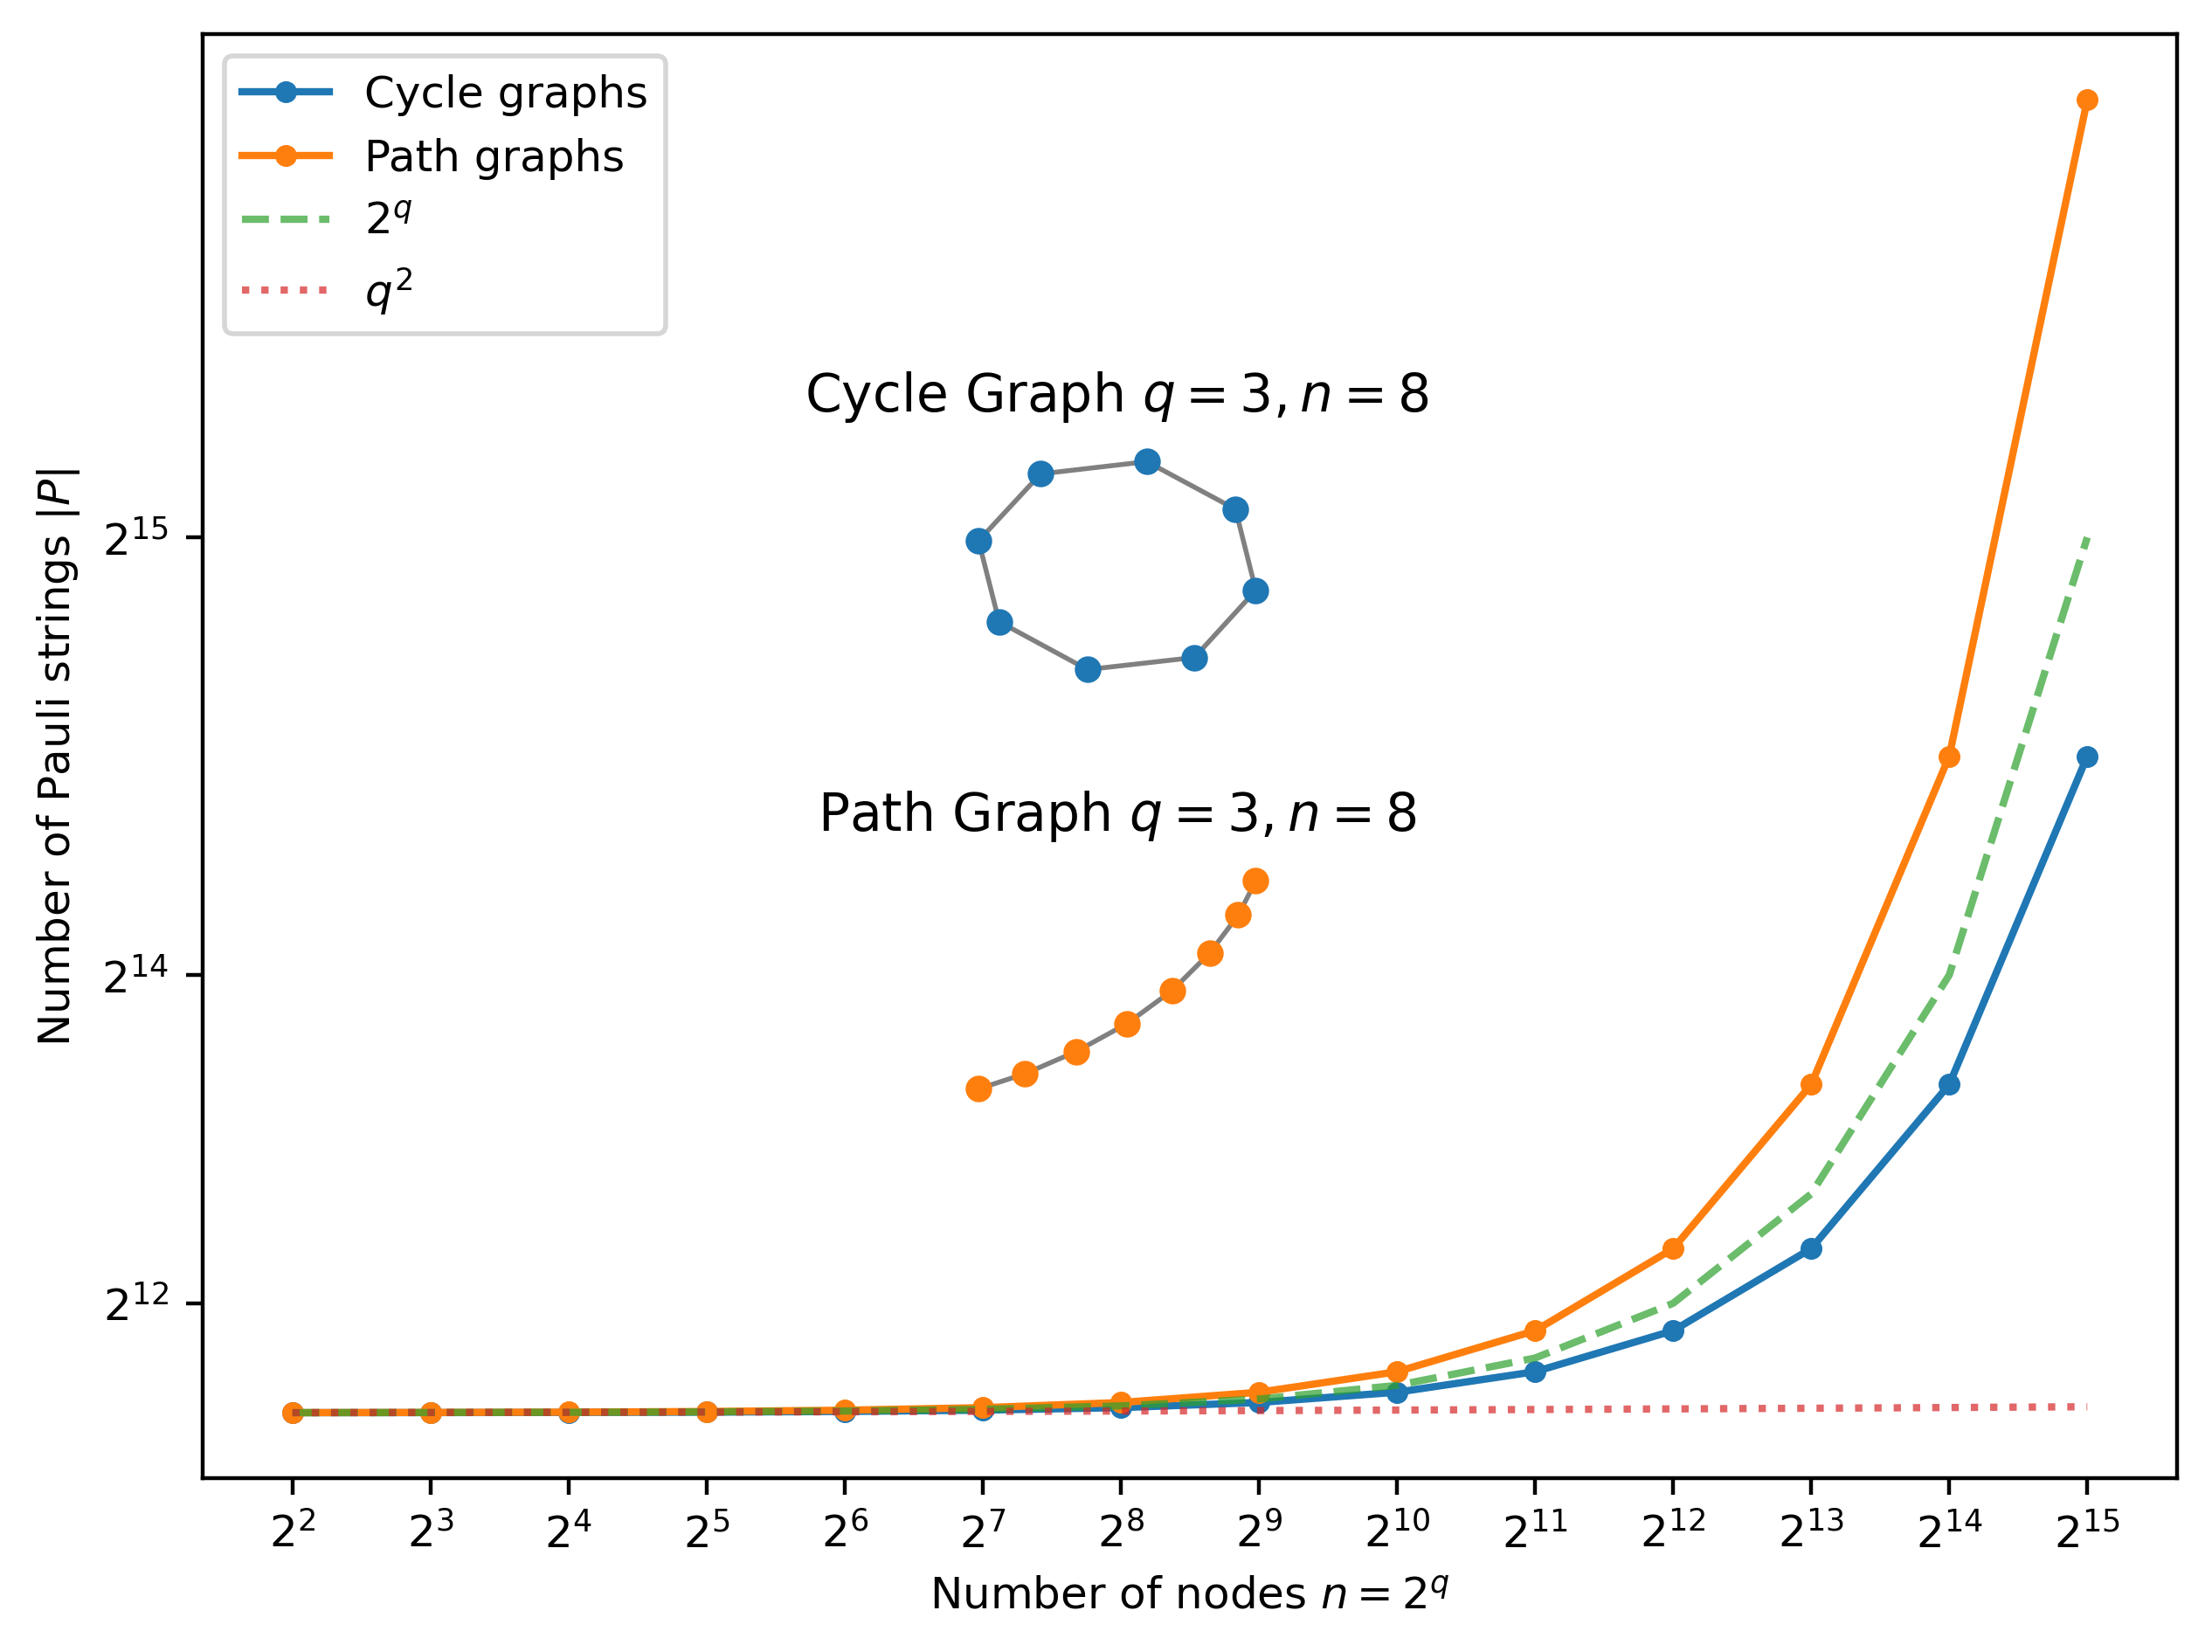

In [2]:
### GENERATING FIGURE CODE ###

import matplotlib.pyplot as plt
import networkx as nx

# Graphics
DPI = 400
DATA_MARKER = "o"
DATA_MARKER_SIZE = 3.5
REF_DATA_ALPHA = 0.7
FONT_SIZE = 9

# --- ADD THIS LINE ---
# This updates the global default for all text elements
plt.rcParams.update({'font.size': FONT_SIZE})

data_graphics = {
    "marker": DATA_MARKER,
    "markersize": DATA_MARKER_SIZE
}

graphs_graphics = {
    "node_size": 20,
    "edge_color": "gray"
}

plt.plot(num_qubits, cycle_num_pauli_strings, label="Cycle graphs", **data_graphics)
plt.plot(num_qubits, path_num_pauli_strings, label="Path graphs", **data_graphics)

plt.plot(num_qubits, 2**num_qubits, "--", alpha=REF_DATA_ALPHA, label="$2^q$")
plt.plot(num_qubits, num_qubits**2, ":", alpha=REF_DATA_ALPHA, label="$q^2$")

plt.xlabel("Number of nodes $n = 2^q$")
plt.ylabel("Number of Pauli strings $|P|$")

plt.xticks(num_qubits, [rf"$2^{{{int(q)}}}$" for q in num_qubits])

y_exponents = [12, 14, 15]
plt.yticks([2**i for i in y_exponents], [rf"$2^{{{i}}}$" for i in y_exponents])

# plt.yscale("log", base=2)
plt.legend()

# Grab the current figure generated by the plt.plot() commands above
fig = plt.gcf()
fig.set_dpi(DPI)

# Add Cycle graph inset (top left blank space)
ax_cycle = fig.add_axes([0.43, 0.58, 0.15, 0.15])
nx.draw(cycle_graphs[1], ax=ax_cycle, node_color="tab:blue", **graphs_graphics)
ax_cycle.set_title(r"Cycle Graph $q = 3, n = 8$")

# Add Path graph inset (directly below the cycle graph)
ax_path = fig.add_axes([0.43, 0.33, 0.15, 0.15])
nx.draw(path_graphs[1], ax=ax_path, node_color='tab:orange', **graphs_graphics)
ax_path.set_title("Path Graph $q = 3, n = 8$")

plt.tight_layout()
plt.savefig("simple_graphs_pauli_decomposition.png", dpi=DPI)
plt.show()

/tmp/ipykernel_17981/2731728129.py:99: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


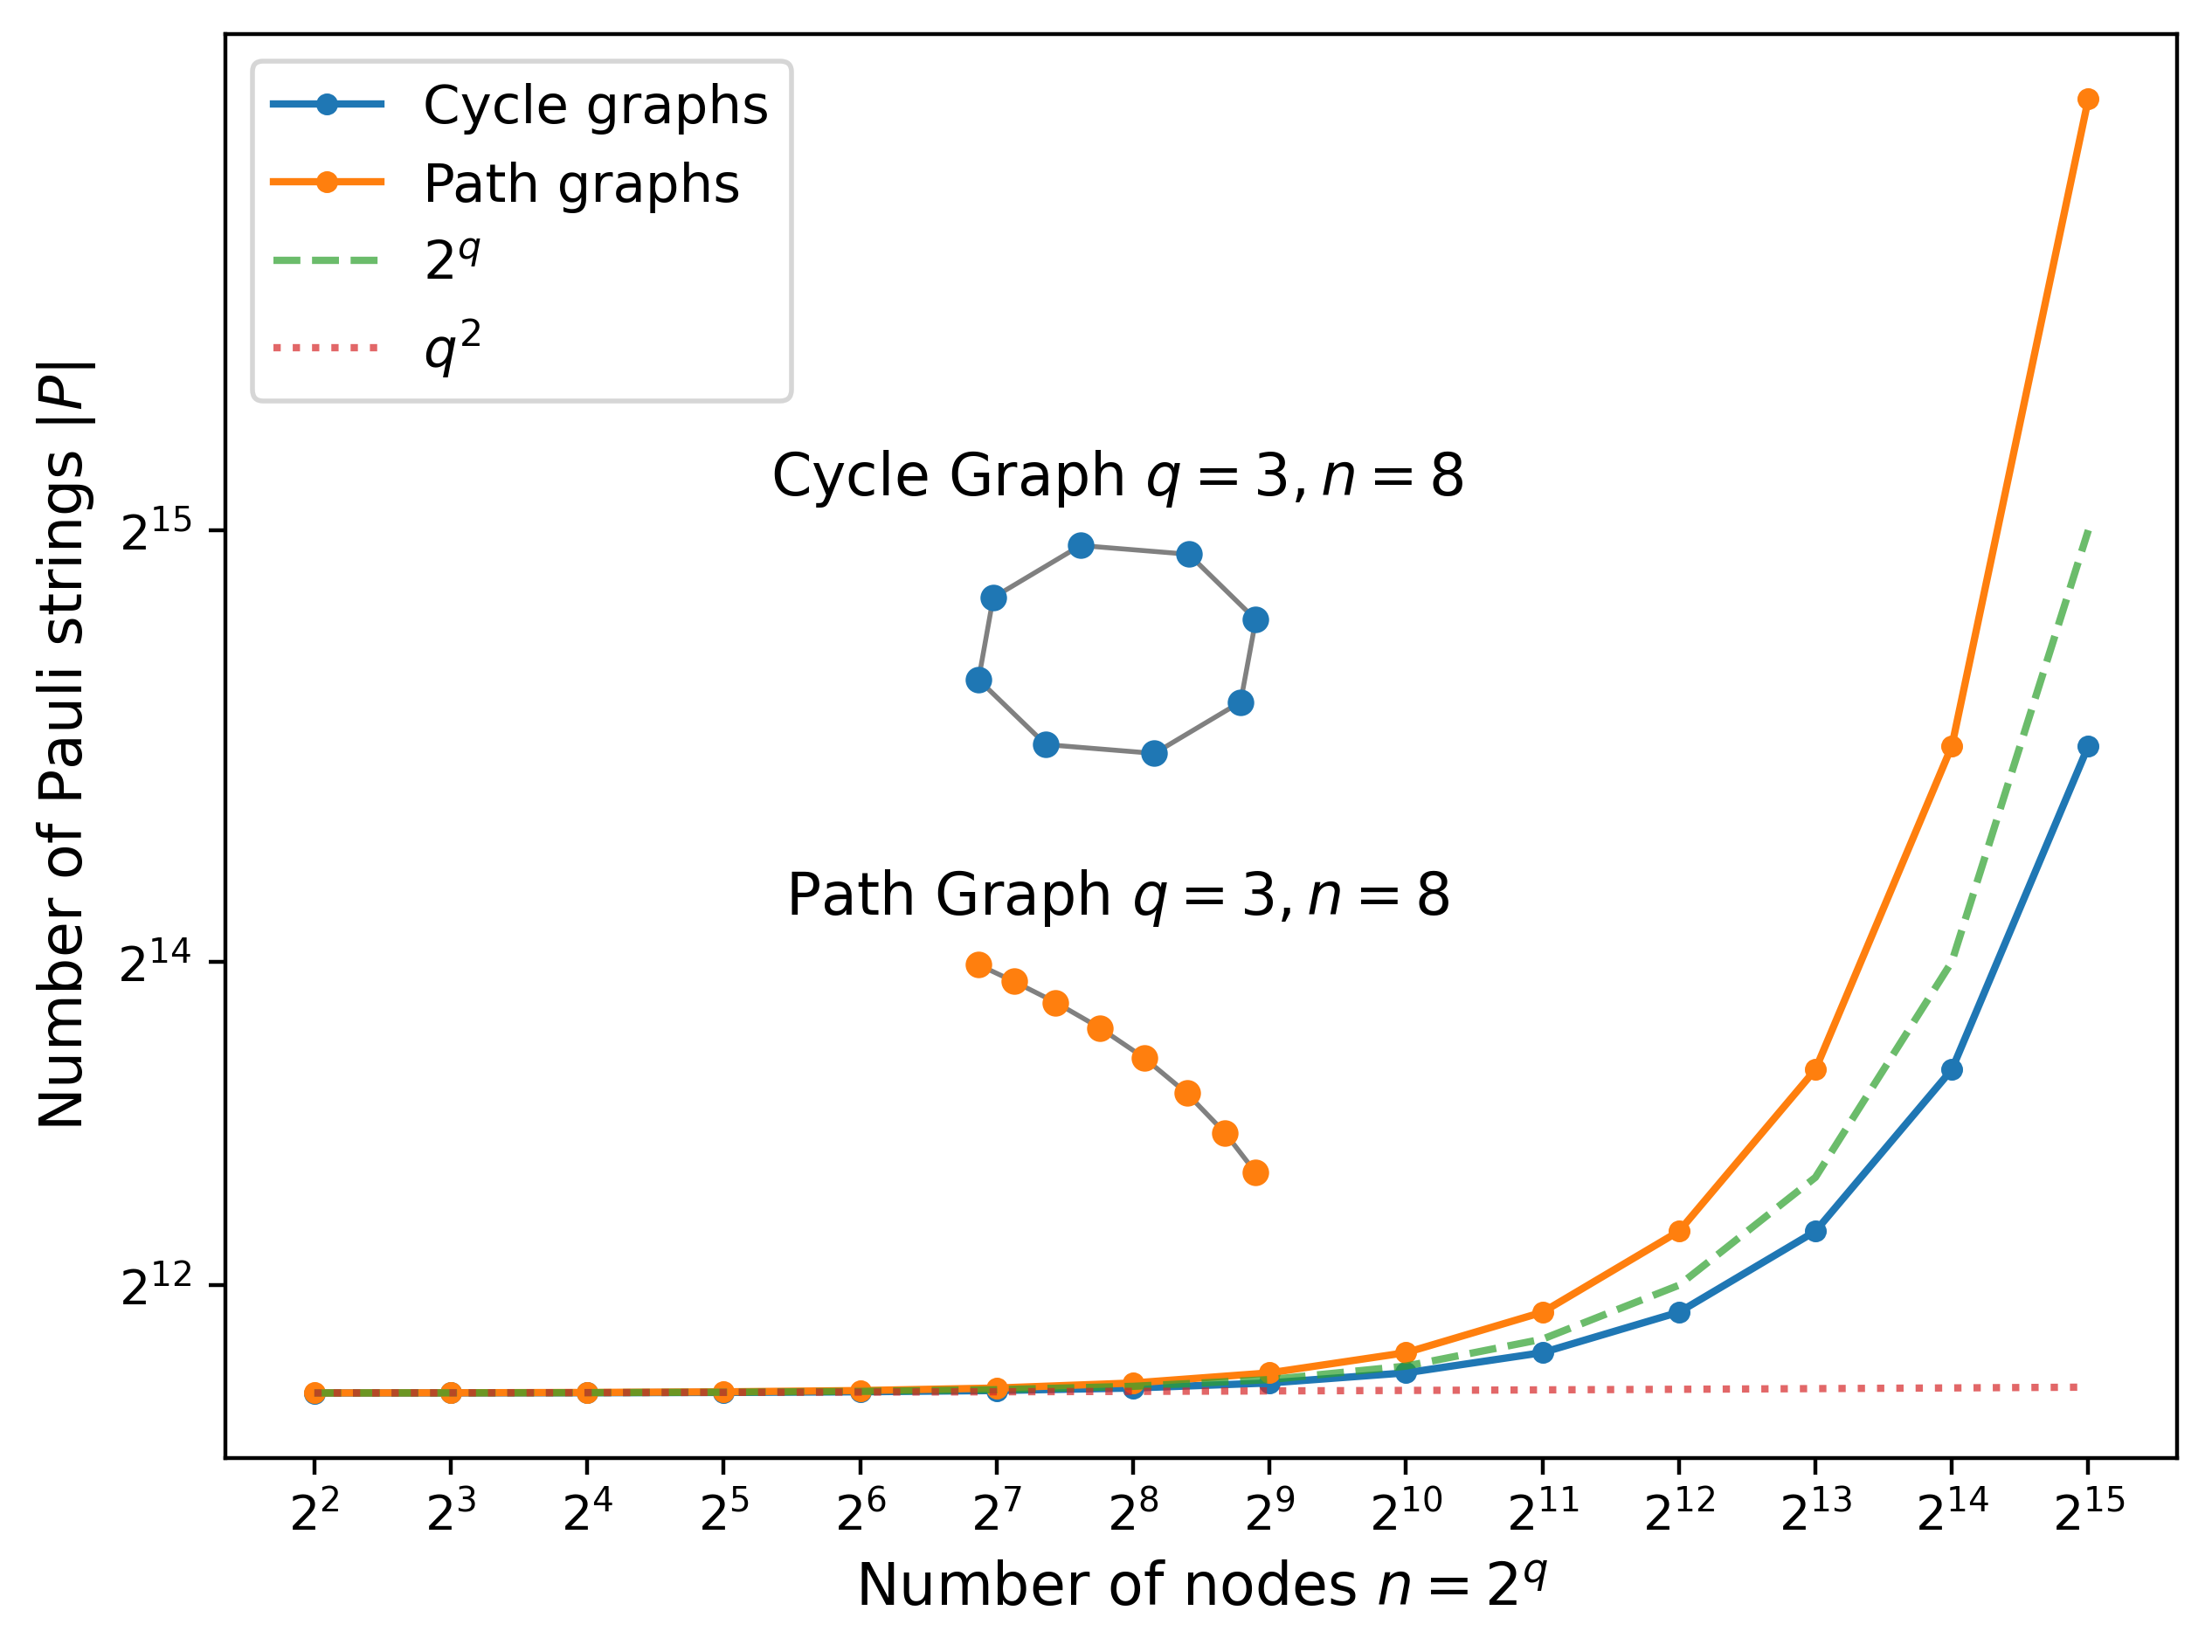

In [6]:
import matplotlib.pyplot as plt
import networkx as nx

# -----------------------------
# GLOBAL STYLE (only minimal)
# -----------------------------
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "figure.dpi": 400
})

# -----------------------------
# FONT HIERARCHY (IMPORTANT)
# -----------------------------
LABEL_FS = 12
TICK_FS = 10
LEGEND_FS = 11
TITLE_FS = 12
INSET_TITLE_FS = 12

DATA_MARKER = "o"
DATA_MARKER_SIZE = 3.5
REF_DATA_ALPHA = 0.7

data_graphics = {
    "marker": DATA_MARKER,
    "markersize": DATA_MARKER_SIZE
}

graphs_graphics = {
    "node_size": 20,
    "edge_color": "gray"
}

# -----------------------------
# MAIN PLOT
# -----------------------------
plt.plot(num_qubits, cycle_num_pauli_strings, label="Cycle graphs", **data_graphics)
plt.plot(num_qubits, path_num_pauli_strings, label="Path graphs", **data_graphics)

plt.plot(num_qubits, 2**num_qubits, "--", alpha=REF_DATA_ALPHA, label="$2^q$")
plt.plot(num_qubits, num_qubits**2, ":", alpha=REF_DATA_ALPHA, label="$q^2$")

plt.xlabel("Number of nodes $n = 2^q$", fontsize=LABEL_FS)
plt.ylabel("Number of Pauli strings $|P|$", fontsize=LABEL_FS)

plt.xticks(
    num_qubits,
    [rf"$2^{{{int(q)}}}$" for q in num_qubits],
    fontsize=TICK_FS
)

y_exponents = [12, 14, 15]
plt.yticks(
    [2**i for i in y_exponents],
    [rf"$2^{{{i}}}$" for i in y_exponents],
    fontsize=TICK_FS
)

plt.legend(fontsize=LEGEND_FS)

# -----------------------------
# INSET: CYCLE GRAPH
# -----------------------------
fig = plt.gcf()

ax_cycle = fig.add_axes([0.43, 0.53, 0.15, 0.15])
nx.draw(
    cycle_graphs[1],
    ax=ax_cycle,
    node_color="tab:blue",
    **graphs_graphics
)
ax_cycle.set_title(
    r"Cycle Graph $q = 3, n = 8$",
    fontsize=INSET_TITLE_FS
)
ax_cycle.tick_params(labelsize=8)

# -----------------------------
# INSET: PATH GRAPH
# -----------------------------
ax_path = fig.add_axes([0.43, 0.28, 0.15, 0.15])
nx.draw(
    path_graphs[1],
    ax=ax_path,
    node_color="tab:orange",
    **graphs_graphics
)
ax_path.set_title(
    "Path Graph $q = 3, n = 8$",
    fontsize=INSET_TITLE_FS
)
ax_path.tick_params(labelsize=8)

# -----------------------------
# LAYOUT
# -----------------------------
plt.tight_layout()
plt.savefig("simple_graphs_pauli_decomposition.png", dpi=400)
plt.show()